<a href="https://colab.research.google.com/github/karanveer-sharma/pythontraining_with_ai/blob/main/decisiontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
path = kagglehub.dataset_download("amineipad/network-anoamly-dataset")
csv_file = os.path.join(path,"networkanomalydataset.csv")
net = pd.read_csv(csv_file)

In [ ]:
net.head()
net.info()
net.shape
net.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1654 entries, 0 to 1653
Data columns (total 5 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Inbound Rate(bit/s)                1654 non-null   float64
 1   Outbound Rate(bit/s)               1654 non-null   float64
 2   Inbound Bandwidth Utilization(%)   1654 non-null   float64
 3   Outbound Bandwidth Utilization(%)  1654 non-null   float64
 4   Label                              1654 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 64.7 KB


,Inbound Rate(bit/s),Outbound Rate(bit/s),Inbound Bandwidth Utilization(%),Outbound Bandwidth Utilization(%),Label
count,1.654000e+03,1.654000e+03,1.654000e+03,1.654000e+03,1654.000000
mean,1.374690e-16,-1.374690e-16,-6.873448e-17,2.062035e-16,0.500000
std,1.000302e+00,1.000302e+00,1.000302e+00,1.000302e+00,0.500151
min,-8.587873e-01,-8.451589e-01,-8.587677e-01,-8.450422e-01,0.000000
25%,-8.071507e-01,-8.063695e-01,-8.072172e-01,-8.064441e-01,0.000000
50%,-7.555341e-01,-7.747574e-01,-7.554490e-01,-7.751713e-01,0.500000
75%,9.628647e-01,1.112895e+00,9.627478e-01,1.112738e+00,1.000000
max,2.122913e+00,1.997753e+00,2.122901e+00,1.998350e+00,1.000000


In [ ]:
X=net.drop('Label',axis=1)
y=net['Label']
X.head(2)

,Inbound Rate(bit/s),Outbound Rate(bit/s),Inbound Bandwidth Utilization(%),Outbound Bandwidth Utilization(%)
0,0.931000,1.224246,0.931001,1.224244
1,0.965773,1.302733,0.965944,1.303585


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
clf=DecisionTreeClassifier(criterion='entropy',max_depth=4, random_state=42)
clf.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [ ]:
y_pred=clf.predict(X_test)


In [ ]:
print("Accuracy",accuracy_score(y_test,y_pred))
print("\nclassifcation report\n",classification_report(y_test,y_pred))
print("\n confusion metrics", confusion_matrix(y_test,y_pred))

Accuracy 0.9979879275653923

classifcation report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       247
           1       1.00      1.00      1.00       250

    accuracy                           1.00       497
   macro avg       1.00      1.00      1.00       497
weighted avg       1.00      1.00      1.00       497


 confusion metrics [[247   0]
 [  1 249]]


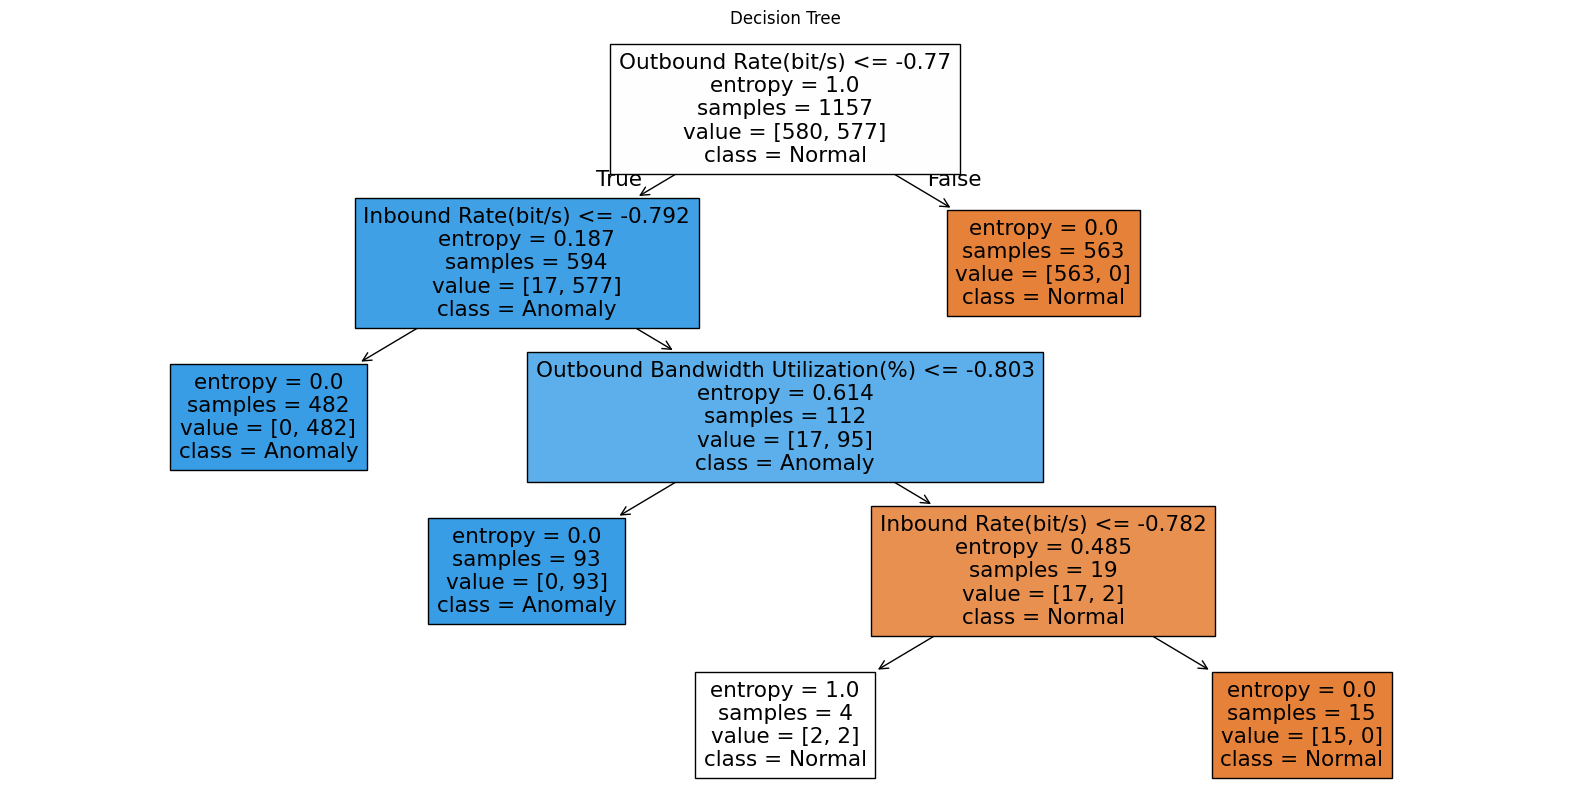

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=["Normal", "Anomaly"], filled=True)
plt.title("Decision Tree")
plt.show()